# Imports

In [1]:
import matplotlib.pyplot as plt
import numpy as np

In [2]:
import sys
import os
import subprocess

sys.path.append(os.path.abspath(os.path.join('..')))

from engine.interop.loader import Loader
from engine.interop.mlp import MLP
from engine.interop.linearModel import LinearModel

try:
    result = subprocess.run(
        "make -C ../libc clean && make -C ../libc",
        shell=True,
        capture_output=True,
        text=True
    )
    # print(result.stdout)

    if result.stderr:
        print(result.stderr)
    
    if result.returncode != 0:
        print(f"Build failed with exit code {result.returncode}")
        sys.exit(1)
    else:
        print("Build succeeded.")

except Exception as e:
    print(f"Build failed: {e}")
    sys.exit(1)

# On doit restart kernel si on veut recharger la lib
try:
    Loader.loadLibrary(
        lib_name="libc",
        lib_folder="../libc",
        build_folder="../libc/build",
        specs_folder="../libc/specs",
        seed=None # ca va generer une seed aleatoire
    )

except Exception as e:
    if "already loaded" not in str(e).lower():
        raise RuntimeError(f"Failed to load library: {e}")
    
    print("Library already loaded, skipping.")

Build succeeded.


# Cas de tests, rendu 2

## Classification

### Linear Simple :
        Linear Model : OK
        MLP (2, 1)   : OK

In [3]:
X = np.array([
      [1, 1],
      [2, 3],
      [3, 3]
])
Y = np.array([
      1,
      -1,
      -1
])

In [4]:
X_norm = (X - np.mean(X, axis=0)) / np.std(X, axis=0)

mlp = MLP([2, 1])
mlp.train(X_norm.flatten().tolist(), Y.tolist(), len(X_norm), 0.01, 5000, True)

pmc_preds = [1 if mlp.predict(x.tolist(), True)[0] >= 0 else -1 for x in X_norm]

print(f"MLP preds: {pmc_preds} (Attendu: {Y.tolist()})")

MLP preds: [1, -1, 1] (Attendu: [1, -1, -1])


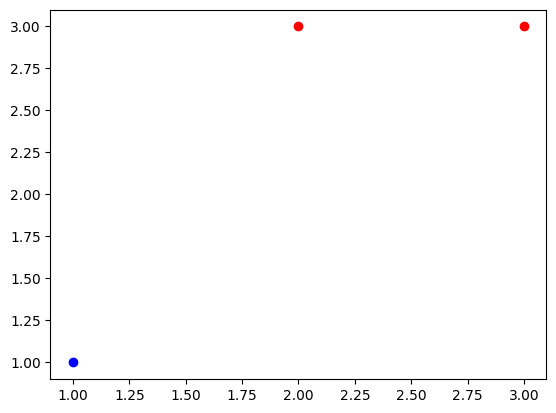

<Figure size 640x480 with 0 Axes>

In [5]:
plt.scatter(X[0, 0], X[0, 1], color='blue')
plt.scatter(X[1:3,0], X[1:3,1], color='red')
plt.show()
plt.clf()

### Linear Multiple :
        Linear Model : OK
        MLP (2, 1)   : OK

In [6]:
X = np.concatenate([np.random.random((50,2)) * 0.9 + np.array([1, 1]), np.random.random((50,2)) * 0.9 + np.array([2, 2])])
Y = np.concatenate([np.ones((50, 1)), np.ones((50, 1)) * -1.0])

In [7]:
X_norm = (X - np.mean(X, axis=0)) / np.std(X, axis=0)
mlp = MLP([2, 1])
mlp.train(X_norm.flatten().tolist(), Y.flatten().tolist(), len(X_norm), 0.01, 5000, True)

pmc_preds = [1 if mlp.predict(x.tolist(), True)[0] >= 0 else -1 for x in X_norm]

erreurs = sum(1 for p, y in zip(pmc_preds, Y.flatten()) if p != y)
print(f"Linear Multiple - MLP a terminé l'entraînement. Nombre d'erreurs : {erreurs} / {len(X_norm)}")

Linear Multiple - MLP a terminé l'entraînement. Nombre d'erreurs : 16 / 100


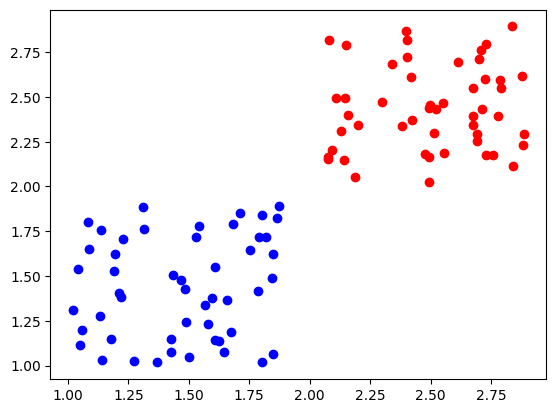

<Figure size 640x480 with 0 Axes>

In [8]:
plt.scatter(X[0:50, 0], X[0:50, 1], color='blue')
plt.scatter(X[50:100,0], X[50:100,1], color='red')
plt.show()
plt.clf()

### XOR :
        Linear Model    : KO
        MLP (2, 2, 1)   : OK

In [9]:
X = np.array([[1, 0], [0, 1], [0, 0], [1, 1]])
Y = np.array([1, 1, -1, -1])

In [10]:

mlp = MLP([2, 2, 1])

mlp.train(X.flatten().tolist(), Y.tolist(), len(X), 0.1, 10000, True)

pmc_preds = [1 if mlp.predict(x.tolist(), True)[0] >= 0 else -1 for x in X]

erreurs = sum(1 for p, y in zip(pmc_preds, Y) if p != y)
print(f"XOR - MLP a terminé l'entraînement. Nombre d'erreurs : {erreurs} / {len(X)}")
print(f"Prédictions : {pmc_preds}")
print(f"Attendu     : {Y.tolist()}")

XOR - MLP a terminé l'entraînement. Nombre d'erreurs : 2 / 4
Prédictions : [-1, -1, -1, -1]
Attendu     : [1, 1, -1, -1]


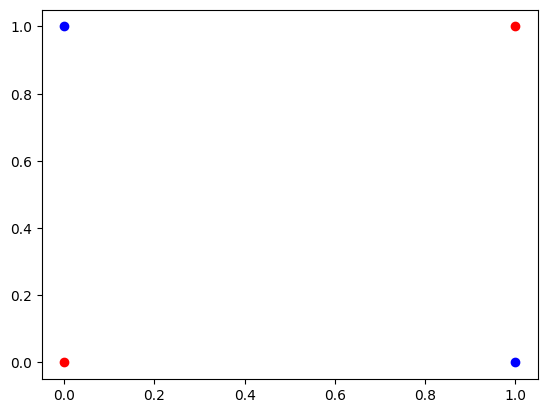

<Figure size 640x480 with 0 Axes>

In [11]:
plt.scatter(X[0:2, 0], X[0:2, 1], color='blue')
plt.scatter(X[2:4,0], X[2:4,1], color='red')
plt.show()
plt.clf()

























































































### Cross :
        Linear Model    : KO
        MLP (2, 4, 1)   : OK

In [12]:
X = np.random.random((500, 2)) * 2.0 - 1.0
Y = np.array([1 if abs(p[0]) <= 0.3 or abs(p[1]) <= 0.3 else -1 for p in X])

In [13]:
mlp = MLP([2, 4, 1])

mlp.train(X.flatten().tolist(), Y.tolist(), len(X), 0.01, 10000, True)

pmc_preds = [1 if mlp.predict(x.tolist(), True)[0] >= 0 else -1 for x in X]

erreurs = sum(1 for p, y in zip(pmc_preds, Y) if p != y)
print(f"Cross - MLP terminé. Erreurs : {erreurs} / {len(X)}")

print(f"10 premières prédictions : {pmc_preds[:10]}")
print(f"10 attendus :            : {Y[:10].tolist()}")

Cross - MLP terminé. Erreurs : 255 / 500
10 premières prédictions : [-1, -1, -1, -1, -1, -1, -1, -1, -1, -1]
10 attendus :            : [-1, -1, 1, -1, -1, 1, 1, -1, -1, -1]


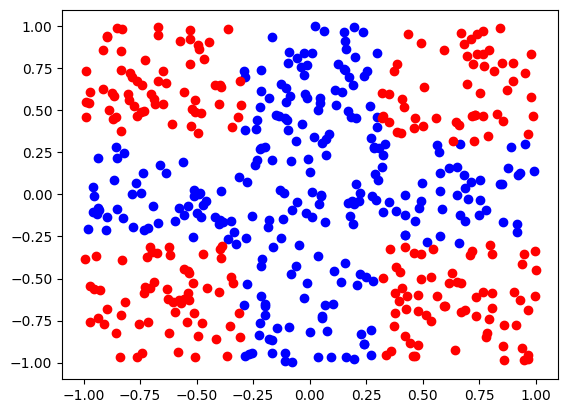

<Figure size 640x480 with 0 Axes>

In [14]:
plt.scatter(np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]] == 1, enumerate(X)))))[:,0], np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]] == 1, enumerate(X)))))[:,1], color='blue')
plt.scatter(np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]] == -1, enumerate(X)))))[:,0], np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]] == -1, enumerate(X)))))[:,1], color='red')
plt.show()
plt.clf()

### Multi Linear 3 classes :
        Linear Model x3 : OK
        MLP (2, 3)      : OK

In [15]:
X = np.random.random((500, 2)) * 2.0 - 1.0
Y = np.array([[1, -1, -1] if -p[0] - p[1] - 0.5 > 0 and p[1] < 0 and p[0] - p[1] - 0.5 < 0 else
              [-1, 1, -1] if -p[0] - p[1] - 0.5 < 0 and p[1] > 0 and p[0] - p[1] - 0.5 < 0 else
              [-1, -1, 1] if -p[0] - p[1] - 0.5 < 0 and p[1] < 0 and p[0] - p[1] - 0.5 > 0 else
              [-1, -1, -1]for p in X])

X = X[[not np.all(arr == [-1, -1, -1]) for arr in Y]]
Y = Y[[not np.all(arr == [-1, -1, -1]) for arr in Y]]

In [16]:
mlp = MLP([2, 8, 3])
mlp.train(X.flatten().tolist(), Y.flatten().tolist(), len(X), 0.01, 20000, True)

pmc_preds = []
for x in X:
    pred = mlp.predict(x.tolist(), True)
    idx_max = np.argmax(pred)
    
    res_vec = [-1, -1, -1]
    res_vec[idx_max] = 1
    pmc_preds.append(res_vec)

erreurs = sum(1 for p, y in zip(pmc_preds, Y.tolist()) if p != y)
print(f"Multi Class - MLP terminé. Erreurs : {erreurs} / {len(X)}")

print(f"Exemple prédiction : {pmc_preds[0]}")
print(f"Exemple attendu    : {Y[0].tolist()}")

Multi Class - MLP terminé. Erreurs : 404 / 404
Exemple prédiction : [1, -1, -1]
Exemple attendu    : [-1, 1, -1]


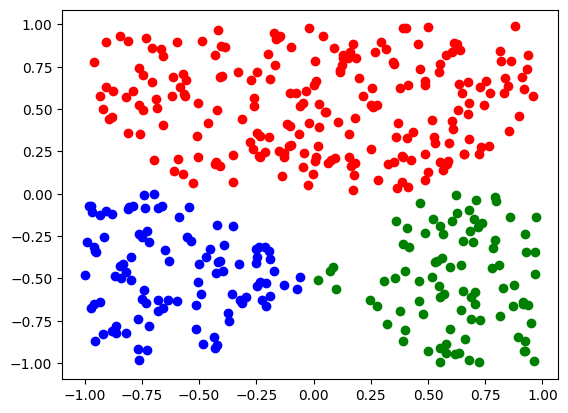

<Figure size 640x480 with 0 Axes>

In [17]:
plt.scatter(np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]][0] == 1, enumerate(X)))))[:,0], np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]][0] == 1, enumerate(X)))))[:,1], color='blue')
plt.scatter(np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]][1] == 1, enumerate(X)))))[:,0], np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]][1] == 1, enumerate(X)))))[:,1], color='red')
plt.scatter(np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]][2] == 1, enumerate(X)))))[:,0], np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]][2] == 1, enumerate(X)))))[:,1], color='green')
plt.show()
plt.clf()

### Multi Cross :
        Linear Model x3 : KO
        MLP (2, ?, ?, 3): OK

In [18]:
X = np.random.random((1000, 2)) * 2.0 - 1.0
Y = np.array([[1, -1, -1] if abs(p[0] % 0.5) <= 0.25 and abs(p[1] % 0.5) > 0.25 else [-1, 1, -1] if abs(p[0] % 0.5) > 0.25 and abs(p[1] % 0.5) <= 0.25 else [-1, -1, 1] for p in X])

In [19]:

mlp = MLP([2, 32, 32, 3])

mlp.train(X.flatten().tolist(), Y.flatten().tolist(), len(X), 0.01, 5000, True)

pmc_preds = []
for x in X:
    pred = mlp.predict(x.tolist(), True)
    idx_max = np.argmax(pred)
    
    res_vec = [-1, -1, -1]
    res_vec[idx_max] = 1
    pmc_preds.append(res_vec)

erreurs = sum(1 for p, y in zip(pmc_preds, Y.tolist()) if p != y)
accuracy = (1 - erreurs/len(X)) * 100

print(f"Multi Cross - MLP terminé.")
print(f"Précision : {accuracy:.2f}% ({len(X) - erreurs} / {len(X)} corrects)")

Multi Cross - MLP terminé.
Précision : 24.70% (247 / 1000 corrects)


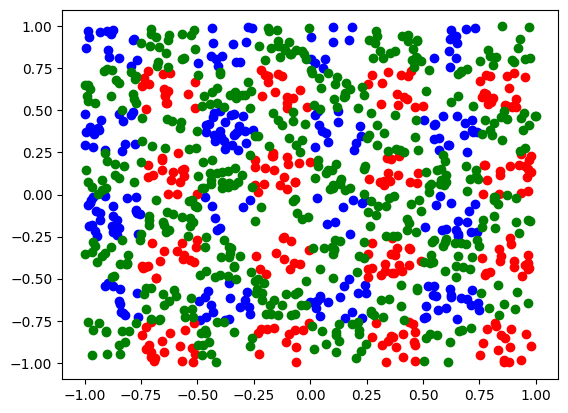

<Figure size 640x480 with 0 Axes>

In [20]:
plt.scatter(np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]][0] == 1, enumerate(X)))))[:,0], np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]][0] == 1, enumerate(X)))))[:,1], color='blue')
plt.scatter(np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]][1] == 1, enumerate(X)))))[:,0], np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]][1] == 1, enumerate(X)))))[:,1], color='red')
plt.scatter(np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]][2] == 1, enumerate(X)))))[:,0], np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]][2] == 1, enumerate(X)))))[:,1], color='green')
plt.show()
plt.clf()

## Régression

### Linear Simple 2D :
        Linear Model : OK
        MLP (1, 1)   : OK

In [21]:
X = np.array([
      [1],
      [2]
])
Y = np.array([
      2,
      3
])

In [22]:
mlp = MLP([1, 1])
mlp.train(X.flatten().tolist(), Y.tolist(), len(X), 0.01, 5000, False)
pmc_preds = [mlp.predict(x.tolist(), False)[0] for x in X]

print(f"MLP Regression preds: {pmc_preds}")
print(f"Valeurs attendues    : {Y.tolist()}")

# Calcul de l'erreur moyenne
mse = np.mean((np.array(pmc_preds) - Y)**2)
print(f"Erreur Quadratique Moyenne (MSE) : {mse:.4f}")

MLP Regression preds: [-0.02280712127685547, 0.20209410786628723]
Valeurs attendues    : [2, 3]
Erreur Quadratique Moyenne (MSE) : 5.9600


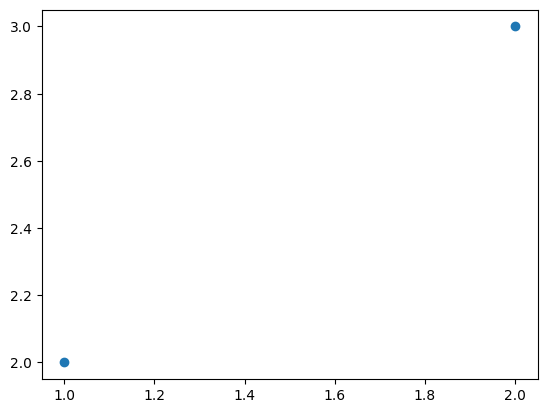

<Figure size 640x480 with 0 Axes>

In [23]:
plt.scatter(X,Y)
plt.show()
plt.clf()

### Non Linear Simple 2D :
        Linear Model    : OK
        MLP (1, ?, 1)   : OK

In [24]:
X = np.array([
      [1],
      [2],
      [3]
])
Y = np.array([
      2,
      3,
      2.5
])

In [25]:
mlp = MLP([1, 4, 1])

mlp.train(X.flatten().tolist(), Y.tolist(), len(X), 0.01, 50000, False)
pmc_preds = [mlp.predict(x.tolist(), False)[0] for x in X]

print(f"MLP Non-Linear preds : {pmc_preds}")
print(f"Valeurs attendues     : {Y.tolist()}")

# Calcul de l'erreur
mse = np.mean((np.array(pmc_preds) - Y)**2)
print(f"Erreur Quadratique Moyenne (MSE) : {mse:.4f}")

MLP Non-Linear preds : [-0.11139219999313354, 1.0377185344696045, 1.5317180156707764]
Valeurs attendues     : [2.0, 3.0, 2.5]
Erreur Quadratique Moyenne (MSE) : 3.0820


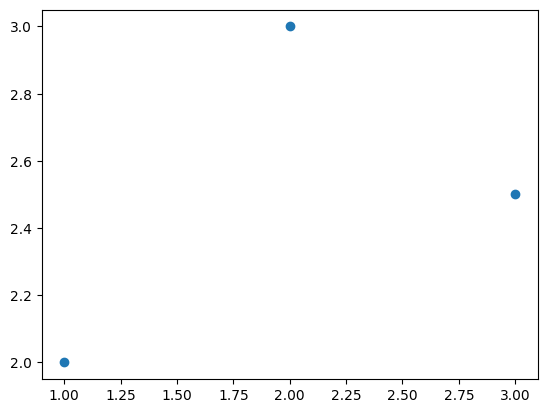

<Figure size 640x480 with 0 Axes>

In [26]:
plt.scatter(X,Y)
plt.show()
plt.clf()

### Linear Simple 3D :
        Linear Model    : OK
        MLP (2, 1)      : OK

In [27]:
X = np.array([
      [1, 1],
      [2, 2],
      [3, 1]
])
Y = np.array([
      2,
      3,
      2.5
])

In [28]:
from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure()
ax = Axes3D(fig)
ax.scatter(X[:,0],X[:,1],Y)
plt.show()
plt.clf()

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

In [29]:
mlp = MLP([2, 1])
mlp.train(X.flatten().tolist(), Y.tolist(), len(X), 0.01, 10000, False)
pmc_preds = [mlp.predict(x.tolist(), False)[0] for x in X]

print(f"MLP 3D Regression preds : {pmc_preds}")
print(f"Valeurs attendues       : {Y.tolist()}")

# Calcul de l'erreur
mse = np.mean((np.array(pmc_preds) - Y)**2)
print(f"Erreur Quadratique Moyenne (MSE) : {mse:.4f}")

MLP 3D Regression preds : [-0.44327986240386963, 0.07799768447875977, -1.061197280883789]
Valeurs attendues       : [2.0, 3.0, 2.5]
Erreur Quadratique Moyenne (MSE) : 9.0633


### Linear Tricky 3D :
        Linear Model    : OK
        MLP (2, 1)      : OK

In [30]:
X = np.array([
      [1, 1],
      [2, 2],
      [3, 3]
])
Y = np.array([
      1,
      2,
      3
])

In [31]:
from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure()
ax = Axes3D(fig)
ax.scatter(X[:,0],X[:,1],Y)
plt.show()
plt.clf()

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

In [32]:
mlp = MLP([2, 1])

mlp.train(X.flatten().tolist(), Y.tolist(), len(X), 0.01, 10000, False)

pmc_preds = [mlp.predict(x.tolist(), False)[0] for x in X]

print(f"MLP Tricky Regression preds : {pmc_preds}")
print(f"Valeurs attendues          : {Y.tolist()}")

mse = np.mean((np.array(pmc_preds) - Y)**2)
print(f"Erreur Quadratique Moyenne (MSE) : {mse:.4f}")

MLP Tricky Regression preds : [0.285207062959671, 0.23756521940231323, 0.18992340564727783]
Valeurs attendues          : [1, 2, 3]
Erreur Quadratique Moyenne (MSE) : 3.8379


### Non Linear Simple 3D :
        Linear Model       : KO
        MLP (2, 2, 1)      : OK

In [33]:
X = np.array([
      [1, 0],
      [0, 1],
      [1, 1],
      [0, 0],
])
Y = np.array([
      2,
      1,
      -2,
      -1
])

In [34]:
mlp = MLP([2, 4, 1]) 
mlp.train(X.flatten().tolist(), Y.tolist(), len(X), 0.001, 50000, False)

pmc_preds = [mlp.predict(x.tolist(), False)[0] for x in X]

print(f"MLP Non-Linear 3D preds : {pmc_preds}")
print(f"Valeurs attendues        : {Y.tolist()}")

# Calcul de l'erreur
mse = np.mean((np.array(pmc_preds) - Y)**2)
print(f"Erreur Quadratique Moyenne (MSE) : {mse:.4f}")

MLP Non-Linear 3D preds : [0.05361859127879143, -0.14512819051742554, -0.1232035756111145, -0.31103333830833435]
Valeurs attendues        : [2, 1, -2, -1]
Erreur Quadratique Moyenne (MSE) : 2.2742


In [35]:
from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure()
ax = Axes3D(fig)
ax.scatter(X[:,0],X[:,1],Y)
plt.show()
plt.clf()

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>